# Estudo da GPD e do DSPOT


## Imports e parâmetros

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import genpareto
from IPython.display import display

# Quantidade de valores usados para calcular a média local
driftDepth = 100

# Quantil que separa o corpo da distribuição da cauda
initialQuantile = 0.98

# Probabilidade extrema desejada
risk = 0.001

# Quantidade de novos picos necessária para reajustar a GPD
refitEvery = 50

# Evita problemas numéricos próximos de zero
tolerancia = 1e-10

print("Parâmetros configurados:")
print(f"driftDepth = {driftDepth}")
print(f"initialQuantile = {initialQuantile}")
print(f"risk = {risk}")
print(f"refitEvery = {refitEvery}")

Parâmetros configurados:
driftDepth = 100
initialQuantile = 0.98
risk = 0.001
refitEvery = 50


## Preparação separada da cauda e da série

Valores usados na calibração inicial: 400
Primeiros valores usados no histórico local: 100
Resíduos esperados na calibração: 300
Valores reservados para o fluxo incremental: 5500


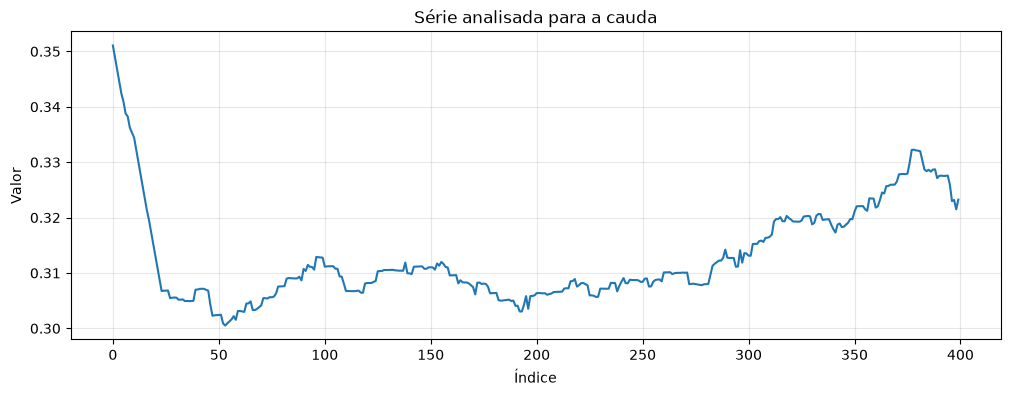

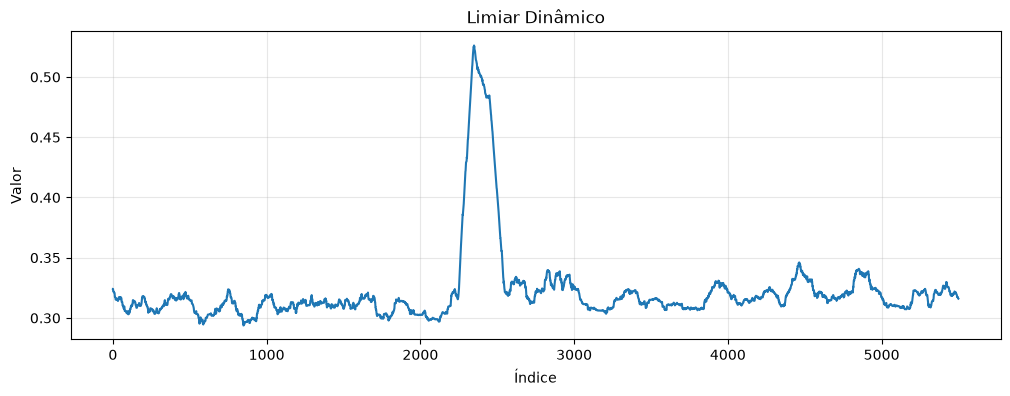

In [65]:
caminhoCSV = "data/AIF_scores.csv"
dados = pd.read_csv(caminhoCSV)
dados_1 = dados.iloc[1100:1500].copy()
dados_2 = dados.iloc[1500:7000].copy()
# colunaSelecionada = "rawScore"
colunaSelecionada = "scoreMa100"

caudaValores = (pd.to_numeric(dados_1[colunaSelecionada], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .to_numpy(dtype=float)
)

serieValores = (pd.to_numeric(dados_2[colunaSelecionada], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .to_numpy(dtype=float)
)

print(f"Valores usados na calibração inicial: {len(caudaValores)}")
print(f"Primeiros valores usados no histórico local: {driftDepth}")
print(f"Resíduos esperados na calibração: {len(caudaValores) - driftDepth}")
print(f"Valores reservados para o fluxo incremental: {len(serieValores)}")

plt.figure(figsize=(12, 4))
plt.plot(caudaValores)
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.title(f"Série analisada para a cauda")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(serieValores)
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.title(f"Limiar Dinâmico")
plt.grid(alpha=0.3)
plt.show()

## Cálculo dos resíduos da calibração

In [66]:
historicoInicial = list(caudaValores[:driftDepth])
residuosCalibracao = []
mediasLocaisCalibracao = []

for valorAtual in caudaValores[driftDepth:]:
    mediaLocal = float(np.mean(historicoInicial))
    residuoAtual = float(valorAtual - mediaLocal)

    mediasLocaisCalibracao.append(mediaLocal)
    residuosCalibracao.append(residuoAtual)

    historicoInicial.append(float(valorAtual))

    if len(historicoInicial) > driftDepth:
        historicoInicial.pop(0)

residuosCalibracao = np.asarray(residuosCalibracao, dtype=float)
mediasLocaisCalibracao = np.asarray(mediasLocaisCalibracao, dtype=float)

## Limiar inicial, picos e excessos

Initial quantile: 0.98
Initial residual threshold: 0.01061568
Quantidade de resíduos: 300
Quantidade de picos: 6
Quantidade de excessos: 6


,pico,excesso
0,0.011584,0.000969
1,0.013732,0.003116
2,0.013527,0.002911
3,0.013158,0.002542
4,0.012862,0.002246
5,0.012520,0.001904


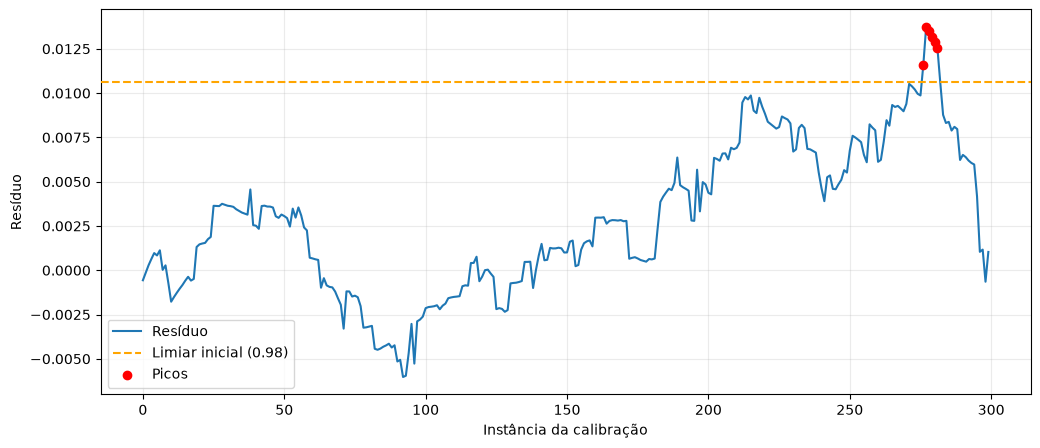

In [67]:
initialResidualThreshold = float(np.quantile(residuosCalibracao, initialQuantile))
picosIniciais = residuosCalibracao[residuosCalibracao > initialResidualThreshold]
excessosIniciais = picosIniciais - initialResidualThreshold

if len(excessosIniciais) < 3:
    raise ValueError(
        f"Foram encontrados apenas {len(excessosIniciais)} excessos. "
        "Reduza initialQuantile ou aumente o tamanho da cauda."
    )

print(f"Initial quantile: {initialQuantile}")
print(f"Initial residual threshold: {initialResidualThreshold:.8f}")
print(f"Quantidade de resíduos: {len(residuosCalibracao)}")
print(f"Quantidade de picos: {len(picosIniciais)}")
print(f"Quantidade de excessos: {len(excessosIniciais)}")

display(pd.DataFrame({
    "pico": picosIniciais,
    "excesso": excessosIniciais,
}))

plt.figure(figsize=(12, 5))
plt.plot(residuosCalibracao, label="Resíduo")
plt.axhline(initialResidualThreshold, linestyle="--", label=f"Limiar inicial ({initialQuantile:.2f})", color="orange", zorder=4)
plt.scatter(np.flatnonzero(residuosCalibracao > initialResidualThreshold), picosIniciais, marker="o", label="Picos", zorder=5, color="red")
plt.xlabel("Instância da calibração")
plt.ylabel("Resíduo")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

## Grimshaw

In [68]:
def funcaoUGrimshaw(x, valores):
    valores = np.asarray(valores, dtype=float)
    termos = 1.0 + x * valores

    if np.any(termos <= 0):
        return np.nan

    return float(np.mean(1.0 / termos))


def funcaoVGrimshaw(x, valores):
    valores = np.asarray(valores, dtype=float)
    termos = 1.0 + x * valores

    if np.any(termos <= 0):
        return np.nan

    return float(1.0 + np.mean(np.log(termos)))


def funcaoWGrimshaw(x, valores):
    u = funcaoUGrimshaw(x, valores)
    v = funcaoVGrimshaw(x, valores)

    if not np.isfinite(u) or not np.isfinite(v):
        return np.nan

    return float(u * v - 1.0)


def logVerossimilhancaGpd(shape, scale, valores):
    valores = np.asarray(valores, dtype=float)

    if not np.isfinite(shape) or not np.isfinite(scale) or scale <= 0:
        return -np.inf

    if abs(shape) < tolerancia:
        return float(-len(valores) * np.log(scale) - np.sum(valores) / scale)

    termos = 1.0 + shape * valores / scale

    if np.any(termos <= 0):
        return -np.inf

    return float(-len(valores) * np.log(scale) - (1.0 + 1.0 / shape) * np.sum(np.log(termos)))

def construirGradeGrimshaw(valores, quantidade=5000):
    valores = np.asarray(valores, dtype=float)
    maiorExcesso = float(np.max(valores))
    mediaExcessos = float(np.mean(valores))

    limiteInferior = -1.0 / maiorExcesso
    margem = max(abs(limiteInferior) * 1e-8, 1e-12)

    gradeNegativa = np.linspace(limiteInferior + margem, -1e-8, quantidade // 2)
    limitePositivo = max(10.0 / max(mediaExcessos, 1e-12), 10.0,)
    gradePositiva = np.geomspace(1e-8, limitePositivo, quantidade // 2)

    return np.concatenate([gradeNegativa, gradePositiva])


def encontrarRaizesGrimshaw(valores):
    grade = construirGradeGrimshaw(valores)
    raizes = []

    xAnterior = grade[0]
    wAnterior = funcaoWGrimshaw(xAnterior, valores)

    for xAtual in grade[1:]:
        wAtual = funcaoWGrimshaw(xAtual, valores)

        if not np.isfinite(wAnterior) or not np.isfinite(wAtual):
            xAnterior = xAtual
            wAnterior = wAtual
            continue

        if wAnterior * wAtual < 0:
            raiz = brentq(lambda x: funcaoWGrimshaw(x, valores), xAnterior, xAtual)

            if abs(raiz) > tolerancia:
                if not any(np.isclose(raiz, existente, atol=1e-8) for existente in raizes):
                    raizes.append(float(raiz))

        xAnterior = xAtual
        wAnterior = wAtual

    return sorted(raizes)


raizesGrimshaw = encontrarRaizesGrimshaw(excessosIniciais)

print(f"Quantidade de raízes não nulas encontradas: {len(raizesGrimshaw)}")
print(raizesGrimshaw)

Quantidade de raízes não nulas encontradas: 7
[1.8765041724285792e-07, 2.1342851401984596e-07, 3.695020981766825e-07, 3.2899492464685708e-06, 3.3254297191509352e-06, 3.440334075024009e-06, 3.864273271362555e-06]


## Construção e comparação dos candidatos

In [69]:
candidatos = []

shapeExponencial = 0.0
scaleExponencial = float(np.mean(excessosIniciais))
logLikelihoodExponencial = logVerossimilhancaGpd(shapeExponencial, scaleExponencial, excessosIniciais)

candidatos.append({
    "origem": "shape = 0",
    "raizX": 0.0,
    "shape": shapeExponencial,
    "scale": scaleExponencial,
    "logLikelihood": logLikelihoodExponencial,
})

for raiz in raizesGrimshaw:
    v = funcaoVGrimshaw(raiz, excessosIniciais)

    shapeCandidato = float(v - 1.0)
    scaleCandidato = float(shapeCandidato / raiz)
    logLikelihood = logVerossimilhancaGpd(shapeCandidato, scaleCandidato, excessosIniciais)

    if np.isfinite(logLikelihood) and scaleCandidato > 0:
        candidatos.append({
            "origem": "raiz Grimshaw",
            "raizX": raiz,
            "shape": shapeCandidato,
            "scale": scaleCandidato,
            "logLikelihood": logLikelihood,
        })

candidatosFrame = (
    pd.DataFrame(candidatos)
    .sort_values("logLikelihood", ascending=False)
    .reset_index(drop=True)
)

display(candidatosFrame)

melhorCandidato = candidatosFrame.iloc[0]
shapeEstimado = float(melhorCandidato["shape"])
scaleEstimado = float(melhorCandidato["scale"])

print(f"Shape selecionado: {shapeEstimado:.10f}")
print(f"Scale selecionado: {scaleEstimado:.10f}")
print(f"Log-verossimilhança: {melhorCandidato['logLikelihood']:.10f}")

,origem,raizX,shape,scale,logLikelihood
0,raiz Grimshaw,3.695021e-07,8.430177e-10,0.002281,30.497543
1,shape = 0,0.000000e+00,0.000000e+00,0.002281,30.497543
2,raiz Grimshaw,3.864273e-06,8.816325e-09,0.002281,30.497543
3,raiz Grimshaw,3.440334e-06,7.849110e-09,0.002281,30.497543
4,raiz Grimshaw,3.325430e-06,7.586956e-09,0.002281,30.497543
5,raiz Grimshaw,3.289949e-06,7.506007e-09,0.002281,30.497543
6,raiz Grimshaw,1.876504e-07,4.281238e-10,0.002281,30.497542
7,raiz Grimshaw,2.134285e-07,4.869365e-10,0.002281,30.497542


Shape selecionado: 0.0000000008
Scale selecionado: 0.0022814963
Log-verossimilhança: 30.4975430378


## Cálculo do primeiro limiar extremo

In [70]:
quantidadeObservacoes = len(residuosCalibracao)
quantidadePicos = len(excessosIniciais)

proporcaoExtrema = (
    risk
    * quantidadeObservacoes
    / quantidadePicos
)

if proporcaoExtrema <= 0:
    raise ValueError("A proporção extrema precisa ser positiva.")

if abs(shapeEstimado) < tolerancia:
    extremeResidualThreshold = (
        initialResidualThreshold
        - scaleEstimado * np.log(proporcaoExtrema)
    )
else:
    extremeResidualThreshold = (
        initialResidualThreshold
        + scaleEstimado
        / shapeEstimado
        * (
            proporcaoExtrema ** (-shapeEstimado)
            - 1.0
        )
    )

print(f"Limiar residual inicial: {initialResidualThreshold:.10f}")
print(f"Limiar residual extremo: {extremeResidualThreshold:.10f}")
print(f"Risk: {risk}")
print(f"Observações da calibração: {quantidadeObservacoes}")
print(f"Picos da calibração: {quantidadePicos}")

Limiar residual inicial: 0.0106156801
Limiar residual extremo: 0.0174504320
Risk: 0.001
Observações da calibração: 300
Picos da calibração: 6


## Funções para reajustar a GPD durante o fluxo

In [71]:
def ajustarGpdGrimshaw(excessos):
    excessos = np.asarray(excessos, dtype=float)

    if len(excessos) < 3:
        raise ValueError("São necessários pelo menos três excessos.")

    candidatosLocais = []

    scaleZero = float(np.mean(excessos))
    logZero = logVerossimilhancaGpd(0.0, scaleZero, excessos)

    candidatosLocais.append({
        "shape": 0.0,
        "scale": scaleZero,
        "logLikelihood": logZero,
    })

    for raiz in encontrarRaizesGrimshaw(excessos):
        shape = float(funcaoVGrimshaw(raiz, excessos) - 1.0)
        scale = float(shape / raiz)
        logLikelihood = logVerossimilhancaGpd(
            shape,
            scale,
            excessos,
        )

        if scale > 0 and np.isfinite(logLikelihood):
            candidatosLocais.append({
                "shape": shape,
                "scale": scale,
                "logLikelihood": logLikelihood,
            })

    melhor = max(
        candidatosLocais,
        key=lambda candidato: candidato["logLikelihood"],
    )

    return float(melhor["shape"]), float(melhor["scale"])


def calcularLimiarExtremo(limiarInicial, shape, scale, quantidadeObservacoes, quantidadePicos, risk):
    proporcao = (risk * quantidadeObservacoes / quantidadePicos)

    if abs(shape) < tolerancia:
        return float(limiarInicial - scale * np.log(proporcao))

    return float(limiarInicial + scale / shape * (proporcao ** (-shape)- 1.0))

## Processamento incremental

In [72]:
historicoLocal = list(caudaValores[-driftDepth:])
excessosAtuais = list(excessosIniciais)

shapeAtual = shapeEstimado
scaleAtual = scaleEstimado
limiarResidualExtremoAtual = extremeResidualThreshold

totalObservacoes = len(residuosCalibracao)
picosDesdeUltimoAjuste = 0

quantidadeCauda = len(caudaValores)
resultadosIncrementais = []

for indiceSerie, valorAtual in enumerate(serieValores):
    indiceGlobal = quantidadeCauda + indiceSerie

    mediaLocal = float(np.mean(historicoLocal))
    residuoAtual = float(valorAtual - mediaLocal)

    limiarInicialAbsoluto = mediaLocal + initialResidualThreshold
    limiarExtremoAbsoluto = mediaLocal + limiarResidualExtremoAtual

    shapeAntes = shapeAtual
    scaleAntes = scaleAtual
    limiarResidualAntes = limiarResidualExtremoAtual

    if residuoAtual <= initialResidualThreshold:
        classificacao = "normal"

        historicoLocal.append(float(valorAtual))

        if len(historicoLocal) > driftDepth:
            historicoLocal.pop(0)

    elif residuoAtual <= limiarResidualExtremoAtual:
        classificacao = "pico"
        novoExcesso = float(residuoAtual - initialResidualThreshold)
        excessosAtuais.append(novoExcesso)
        picosDesdeUltimoAjuste += 1
        historicoLocal.append(float(valorAtual))

        if len(historicoLocal) > driftDepth:
            historicoLocal.pop(0)

    else:
        classificacao = "anomalia"

    totalObservacoes += 1
    reajustouCauda = False

    if (classificacao == "pico" and picosDesdeUltimoAjuste >= refitEvery):
        shapeAtual, scaleAtual = ajustarGpdGrimshaw(excessosAtuais)
        limiarResidualExtremoAtual = calcularLimiarExtremo(
            initialResidualThreshold,
            shapeAtual,
            scaleAtual,
            totalObservacoes,
            len(excessosAtuais),
            risk,
        )

        picosDesdeUltimoAjuste = 0
        reajustouCauda = True

    resultadosIncrementais.append({
        "indiceSerie": indiceSerie,
        "indiceGlobal": indiceGlobal,
        "valor": valorAtual,
        "mediaLocal": mediaLocal,
        "residuo": residuoAtual,
        "limiarInicial": limiarInicialAbsoluto,
        "limiarExtremo": limiarExtremoAbsoluto,
        "classificacao": classificacao,
        "shapeAntes": shapeAntes,
        "scaleAntes": scaleAntes,
        "limiarResidualAntes": limiarResidualAntes,
        "shape": shapeAtual,
        "scale": scaleAtual,
        "limiarResidualAtual": limiarResidualExtremoAtual,
        "quantidadeExcessos": len(excessosAtuais),
        "picosDesdeUltimoAjuste": picosDesdeUltimoAjuste,
        "reajustouCauda": reajustouCauda,
    })

resultadoSerie = pd.DataFrame(resultadosIncrementais)

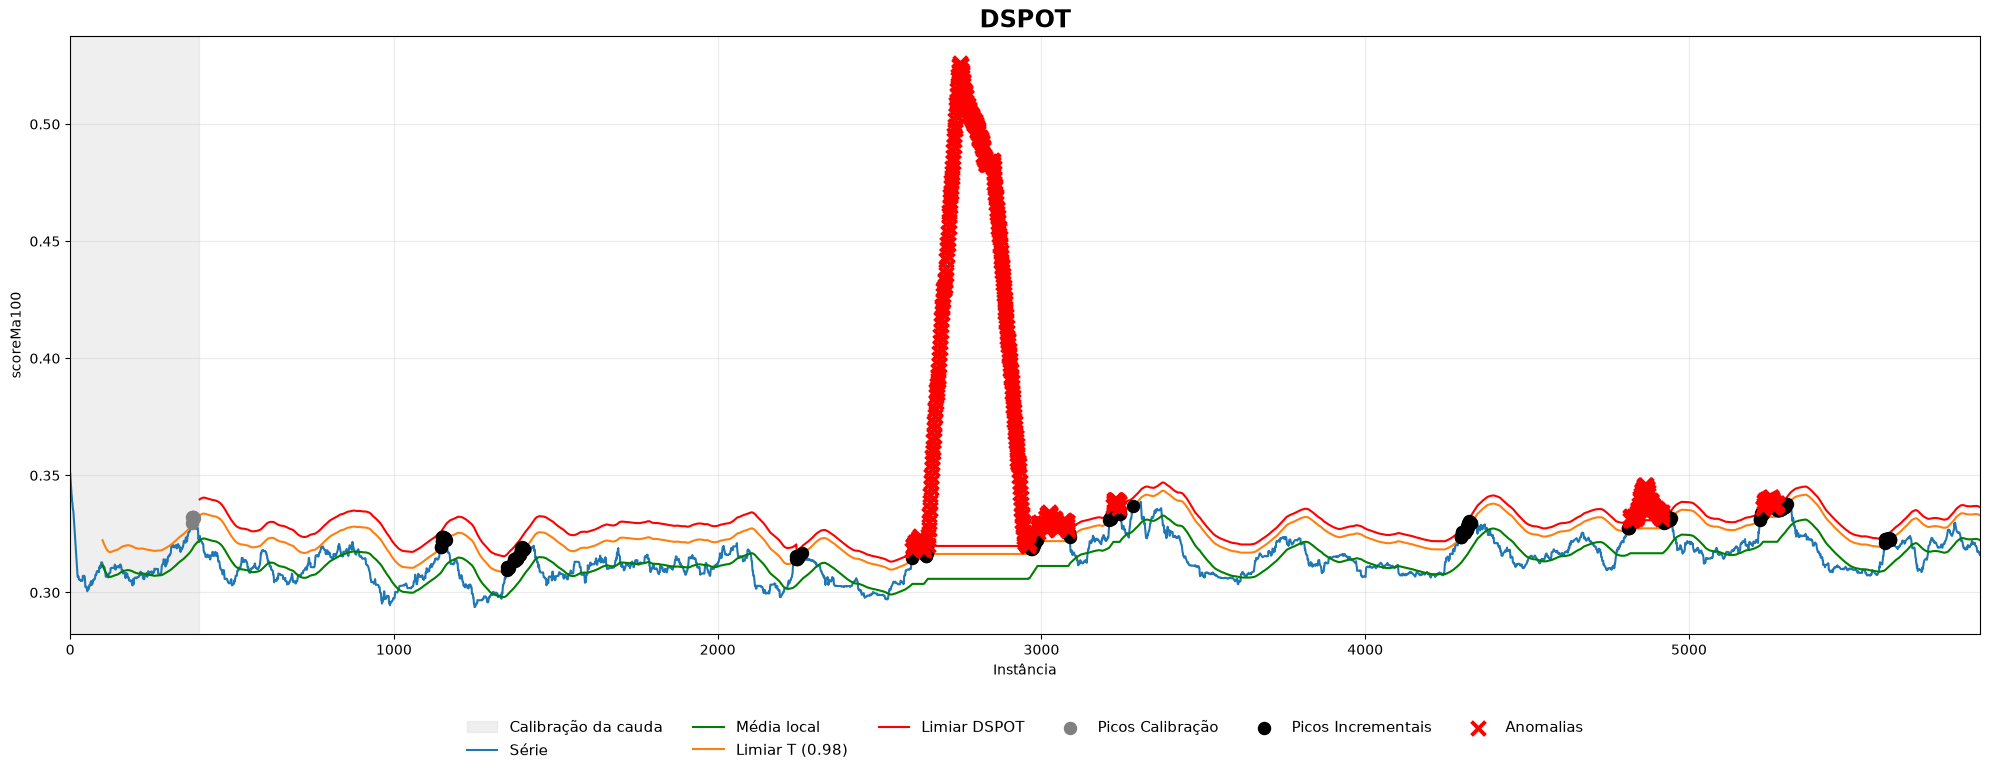

In [73]:
from python.Plot import DspotPlot

DspotPlot.plot(
    caudaValores=caudaValores,
    resultadoSerie=resultadoSerie,
    residuosCalibracao=residuosCalibracao,
    mediasLocaisCalibracao=mediasLocaisCalibracao,
    initialResidualThreshold=initialResidualThreshold,
    initialQuantile=initialQuantile,
    driftDepth=driftDepth,
    colunaSelecionada=colunaSelecionada,
)